# Activity Recognition Using Sensor Data 

Import packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
from scipy.stats import norm
from scipy.stats import bootstrap
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

Get the AReM Data Set

In [2]:
def create_activity_df(activity, num_files):
    df_list = []
    keys_list = [f'{activity}_dataset{j}' for j in range(1, num_files + 1)]

    for i in range(1, num_files + 1):
        df = pd.read_csv(f'../data/AReM/{activity}/dataset{i}.csv', skiprows=4, usecols=range(7))
        df = df.rename(columns={df.columns[0]: 'time'})
        
        if i == 1:
            time_index = df['time']
    
        df = df.drop(columns=['time'])
        df_list.append(df)
        
    combined_df = pd.concat(df_list, axis=1, keys=keys_list, names=['Dataset', 'Column'])
    combined_df.index = time_index
    return combined_df

In [3]:
activity_df_list = []
activity_info = {'bending1':7, 'bending2':6, 'cycling':15, 'lying':15, 'sitting':15, 'standing':15, 'walking':15}

for activity in activity_info:
    activity_df = create_activity_df(activity, activity_info[activity])
    activity_df_list.append(activity_df)

arem_df = pd.concat(activity_df_list, axis=1)
arem_df

Dataset bending1_dataset1                                                    \
Column          avg_rss12 var_rss12 avg_rss13 var_rss13 avg_rss23 var_rss23   
time                                                                          
0                   39.25      0.43     22.75      0.43     33.75       1.3   
250                 39.25      0.43     23.00      0.00     33.00       0.0   
500                 39.25      0.43     23.25      0.43     33.00       0.0   
750                 39.50      0.50     23.00      0.71     33.00       0.0   
1000                39.50      0.50     24.00      0.00     33.00       0.0   
...                   ...       ...       ...       ...       ...       ...   
118750              43.33      0.47     25.00      0.00     30.00       0.0   
119000              43.50      0.50     25.50      0.50     30.00       0.0   
119250              43.50      0.50     24.75      0.43     30.00       0.0   
119500              43.50      0.50     24.33      0.47     30.00       0.0   
119750              43.50      0.50     24.25      0.43     30.00       0.0   

Dataset bending1_dataset2                                ...  \
Column          avg_rss12 var_rss12 avg_rss13 var_rss13  ...   
time                                                     ...   
0                   43.67      0.47     24.75      0.43  ...   
250                 43.33      0.47     25.33      0.47  ...   
500                 42.75      0.83     25.25      0.83  ...   
750                 41.75      0.43     20.50      3.35  ...   
1000                42.50      0.50     20.75      4.55  ...   
...                   ...       ...       ...       ...  ...   
118750              43.00      0.71      9.50      2.18  ...   
119000              43.25      0.83     12.25      0.43  ...   
119250              43.50      0.50     13.00      2.35  ...   
119500              43.75      0.43     15.75      1.92  ...   
119750              43.25      0.83     20.75      0.43  ...   

Dataset walking_dataset14                               walking_dataset15  \
Column          avg_rss13 var_rss13 avg_rss23 var_rss23         avg_rss12   
time                                                                        
0                   14.50      2.29     17.00      4.58             37.75   
250                 16.75      2.86     20.00      2.12             35.25   
500                 16.67      1.70     16.33      3.09             38.33   
750                 21.25      2.77     17.00      1.22             40.50   
1000                18.50      3.50     16.00      2.83             30.00   
...                   ...       ...       ...       ...               ...   
118750              10.00      2.16      7.00      4.85             34.50   
119000              12.50      1.66     10.75      4.49             25.75   
119250              15.75      2.05     14.00      4.42             31.50   
119500              18.00      1.87     17.00      3.67             33.75   
119750              16.50      1.50     16.50      3.35             37.00   

Dataset                                                    
Column  var_rss12 avg_rss13 var_rss13 avg_rss23 var_rss23  
time                                                       
0            8.93     16.25      5.07     17.00      4.36  
250          2.49     11.33      4.92     13.67      2.36  
500          3.86     19.25      1.48     18.67      2.05  
750          3.57     17.50      1.80     16.00      6.20  
1000         0.00     19.67      1.89     16.75      3.42  
...           ...       ...       ...       ...       ...  
118750       6.18      9.00      3.56     12.67      4.19  
119000       6.02     13.75      2.05     16.00      1.58  
119250       3.35     10.25      5.12     16.25      2.95  
119500       2.77     14.00      3.24     13.75      0.43  
119750       1.41     18.25      3.70     11.00      4.32  

[480 rows x 528 columns]

# Splitting Data

In [4]:
activity_list = list(activity_info.keys())
all_col = [f'{act}_dataset{k}' for act in activity_list for k in range(1,activity_info[act] + 1)]

test_col = [[f'{act}_dataset{k}' for act in activity_list[:2] for k in range(1,3)], [f'{act}_dataset{l}' for act in activity_list[2:] for l in range(1,4)]]
test_col = [col for sublist in test_col for col in sublist]
training_col = [col for col in all_col if col not in test_col]

print("# of Training Instances:", len(training_col))
print("# of Testing Instances:", len(test_col))

# of Training Instances: 69
# of Testing Instances: 19


In [5]:
train_set = arem_df[training_col]
test_set = arem_df[test_col]
train_set

Dataset bending1_dataset3                                                    \
Column          avg_rss12 var_rss12 avg_rss13 var_rss13 avg_rss23 var_rss23   
time                                                                          
0                   42.00      0.71     21.25      0.43     30.00      0.00   
250                 41.50      0.50     20.25      1.48     31.25      1.09   
500                 41.50      0.50     14.25      1.92     33.00      0.00   
750                 40.75      0.83     15.75      0.43     33.00      0.00   
1000                40.00      0.71     20.00      2.74     32.75      0.43   
...                   ...       ...       ...       ...       ...       ...   
118750              42.50      0.50     20.00      0.82     36.00      0.00   
119000              42.67      0.47     21.00      0.00     36.33      0.47   
119250              44.33      0.94     21.00      0.00     36.33      0.47   
119500              45.25      0.43     26.75      1.79     36.00      0.00   
119750              47.25      0.83     29.75      0.43     35.25      1.30   

Dataset bending1_dataset4                                ...  \
Column          avg_rss12 var_rss12 avg_rss13 var_rss13  ...   
time                                                     ...   
0                   47.33      0.47     28.00      0.82  ...   
250                 47.50      0.50     29.00      1.22  ...   
500                 47.50      0.50     30.00      0.00  ...   
750                 47.00      0.71     28.00      1.22  ...   
1000                45.00      0.71     24.25      1.79  ...   
...                   ...       ...       ...       ...  ...   
118750              39.00      0.00     11.50      4.72  ...   
119000              41.50      0.50     22.25      1.92  ...   
119250              42.00      0.00     23.50      0.87  ...   
119500              42.50      0.50     21.00      0.00  ...   
119750              43.25      0.43     23.75      0.43  ...   

Dataset walking_dataset14                               walking_dataset15  \
Column          avg_rss13 var_rss13 avg_rss23 var_rss23         avg_rss12   
time                                                                        
0                   14.50      2.29     17.00      4.58             37.75   
250                 16.75      2.86     20.00      2.12             35.25   
500                 16.67      1.70     16.33      3.09             38.33   
750                 21.25      2.77     17.00      1.22             40.50   
1000                18.50      3.50     16.00      2.83             30.00   
...                   ...       ...       ...       ...               ...   
118750              10.00      2.16      7.00      4.85             34.50   
119000              12.50      1.66     10.75      4.49             25.75   
119250              15.75      2.05     14.00      4.42             31.50   
119500              18.00      1.87     17.00      3.67             33.75   
119750              16.50      1.50     16.50      3.35             37.00   

Dataset                                                    
Column  var_rss12 avg_rss13 var_rss13 avg_rss23 var_rss23  
time                                                       
0            8.93     16.25      5.07     17.00      4.36  
250          2.49     11.33      4.92     13.67      2.36  
500          3.86     19.25      1.48     18.67      2.05  
750          3.57     17.50      1.80     16.00      6.20  
1000         0.00     19.67      1.89     16.75      3.42  
...           ...       ...       ...       ...       ...  
118750       6.18      9.00      3.56     12.67      4.19  
119000       6.02     13.75      2.05     16.00      1.58  
119250       3.35     10.25      5.12     16.25      2.95  
119500       2.77     14.00      3.24     13.75      0.43  
119750       1.41     18.25      3.70     11.00      4.32  

[480 rows x 414 columns]

# Feature Extraction

Common Time-Domain Features:

1. Mean
2. Median
3. Minimum
4. Maximum
5. Range
6. Standard Deviation
7. Variance
8. Quantiles
9. IQR
10. Skewness
11. Kurtosis
12. Root Mean Square
13. Entropy

ii. Extraction

In [6]:
def compute_features(instance):
    all_features = {}
    i = 0
    for col in instance:
        i += 1
        td_features = {f'min_{i}': instance[col].min(), f'max_{i}': instance[col].max(), f'mean_{i}': instance[col].mean(), 
                       f'median_{i}': instance[col].median(), f'std_{i}': instance[col].std(), f'1st_quartile_{i}': instance[col].quantile(0.25),
                       f'3rd_quartile_{i}': instance[col].quantile(0.75)}

        all_features.update(td_features)

    return pd.DataFrame([all_features])

In [7]:
feature_df = compute_features(arem_df[all_col[0]])
for instance in all_col[1:]:
    new_row = compute_features(arem_df[instance])
    feature_df = pd.concat([feature_df, new_row])

feature_df = feature_df.reset_index(drop=True)  
feature_df.index = feature_df.index + 1  
feature_df.index.name = 'Instance'  
feature_df

,min_1,max_1,mean_1,median_1,std_1,1st_quartile_1,3rd_quartile_1,min_2,max_2,mean_2,...,std_5,1st_quartile_5,3rd_quartile_5,min_6,max_6,mean_6,median_6,std_6,1st_quartile_6,3rd_quartile_6
Instance,,,,,,,,,,,,,,,,,,,,,
1,37.25,45.00,40.624792,40.50,1.476967,39.25,42.0000,0.0,1.30,0.358604,...,2.188449,33.0000,36.00,0.00,1.92,0.570583,0.43,0.582915,0.0000,1.3000
2,38.00,45.67,42.812812,42.50,1.435550,42.00,43.6700,0.0,1.22,0.372437,...,1.995255,32.0000,34.50,0.00,3.11,0.571083,0.43,0.601010,0.0000,1.3000
3,35.00,47.40,43.954500,44.33,1.558835,43.00,45.0000,0.0,1.70,0.426250,...,1.999604,35.3625,36.50,0.00,1.79,0.493292,0.43,0.513506,0.0000,0.9400
4,33.00,47.75,42.179812,43.50,3.670666,39.15,45.0000,0.0,3.00,0.696042,...,3.849448,30.4575,36.33,0.00,2.18,0.613521,0.50,0.524317,0.0000,1.0000
5,33.00,45.75,41.678063,41.75,2.243490,41.33,42.7500,0.0,2.83,0.535979,...,2.411026,28.4575,31.25,0.00,1.79,0.383292,0.43,0.389164,0.0000,0.5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,19.50,45.33,33.586875,34.25,4.650935,30.25,37.0000,0.0,14.67,4.576562,...,3.283983,13.7300,18.25,0.00,8.32,3.259729,3.11,1.640243,2.0500,4.3225
85,19.75,45.50,34.322750,35.25,4.752477,31.00,38.0000,0.0,13.47,4.456333,...,3.119856,13.5000,17.75,0.00,9.67,3.432563,3.20,1.732727,2.1575,4.5650
86,19.50,46.00,34.546229,35.25,4.842294,31.25,37.8125,0.0,12.47,4.371958,...,2.823124,14.0000,17.75,0.00,10.00,3.338125,3.08,1.656742,2.1600,4.3350


In [8]:
training_df = compute_features(train_set[training_col[0]])
for instance in training_col[1:]:
    new_row = compute_features(train_set[instance])
    training_df = pd.concat([training_df, new_row])

training_df = training_df.reset_index(drop=True)  
training_df.index = training_df.index + 1  
training_df.index.name = 'Instance'  
training_df

,min_1,max_1,mean_1,median_1,std_1,1st_quartile_1,3rd_quartile_1,min_2,max_2,mean_2,...,std_5,1st_quartile_5,3rd_quartile_5,min_6,max_6,mean_6,median_6,std_6,1st_quartile_6,3rd_quartile_6
Instance,,,,,,,,,,,,,,,,,,,,,
1,35.00,47.40,43.954500,44.33,1.558835,43.00,45.0000,0.0,1.70,0.426250,...,1.999604,35.3625,36.50,0.00,1.79,0.493292,0.43,0.513506,0.0000,0.9400
2,33.00,47.75,42.179812,43.50,3.670666,39.15,45.0000,0.0,3.00,0.696042,...,3.849448,30.4575,36.33,0.00,2.18,0.613521,0.50,0.524317,0.0000,1.0000
3,33.00,45.75,41.678063,41.75,2.243490,41.33,42.7500,0.0,2.83,0.535979,...,2.411026,28.4575,31.25,0.00,1.79,0.383292,0.43,0.389164,0.0000,0.5000
4,37.00,48.00,43.454958,43.25,1.386098,42.50,45.0000,0.0,1.58,0.378083,...,2.488862,22.2500,24.00,0.00,5.26,0.679646,0.50,0.622534,0.4300,0.8700
5,36.25,48.00,43.969125,44.50,1.618364,43.31,44.6700,0.0,1.50,0.413125,...,3.318301,20.5000,23.75,0.00,2.96,0.555312,0.49,0.487826,0.0000,0.8300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,19.50,45.33,33.586875,34.25,4.650935,30.25,37.0000,0.0,14.67,4.576562,...,3.283983,13.7300,18.25,0.00,8.32,3.259729,3.11,1.640243,2.0500,4.3225
66,19.75,45.50,34.322750,35.25,4.752477,31.00,38.0000,0.0,13.47,4.456333,...,3.119856,13.5000,17.75,0.00,9.67,3.432563,3.20,1.732727,2.1575,4.5650
67,19.50,46.00,34.546229,35.25,4.842294,31.25,37.8125,0.0,12.47,4.371958,...,2.823124,14.0000,17.75,0.00,10.00,3.338125,3.08,1.656742,2.1600,4.3350


In [9]:
test_df = compute_features(test_set[test_col[0]])
for instance in test_col[1:]:
    new_row = compute_features(test_set[instance])
    test_df = pd.concat([test_df, new_row])

test_df = test_df.reset_index(drop=True)  
test_df.index = test_df.index + 1  
test_df.index.name = 'Instance'  
test_df

,min_1,max_1,mean_1,median_1,std_1,1st_quartile_1,3rd_quartile_1,min_2,max_2,mean_2,...,std_5,1st_quartile_5,3rd_quartile_5,min_6,max_6,mean_6,median_6,std_6,1st_quartile_6,3rd_quartile_6
Instance,,,,,,,,,,,,,,,,,,,,,
1,37.25,45.00,40.624792,40.500,1.476967,39.2500,42.0000,0.0,1.30,0.358604,...,2.188449,33.0000,36.0000,0.0,1.92,0.570583,0.430,0.582915,0.0000,1.300
2,38.00,45.67,42.812812,42.500,1.435550,42.0000,43.6700,0.0,1.22,0.372437,...,1.995255,32.0000,34.5000,0.0,3.11,0.571083,0.430,0.601010,0.0000,1.300
3,12.75,51.00,24.562958,24.250,3.737514,23.1875,26.5000,0.0,6.87,0.590833,...,3.693786,20.5000,27.0000,0.0,4.97,0.700188,0.500,0.693720,0.4300,0.870
4,0.00,42.75,27.464604,28.000,3.583582,25.5000,30.0000,0.0,7.76,0.449708,...,5.053642,15.0000,20.7500,0.0,6.76,1.122125,0.830,1.012342,0.4700,1.300
5,24.25,45.00,37.177042,36.250,3.581301,34.5000,40.2500,0.0,8.58,2.374208,...,2.890347,17.9500,21.7500,0.0,9.34,2.921729,2.500,1.852600,1.5000,3.900
6,28.75,44.75,37.561187,36.875,3.226507,35.2500,40.2500,0.0,9.91,2.080687,...,2.727377,18.0000,21.5000,0.0,9.62,2.765896,2.450,1.769203,1.4100,3.770
7,22.00,44.67,37.058708,36.000,3.710180,34.5000,40.0625,0.0,14.17,2.438146,...,3.537144,16.0000,21.0000,0.0,8.55,2.983750,2.570,1.815730,1.5000,4.150
8,23.50,30.00,27.716375,27.500,1.442253,27.0000,29.0000,0.0,1.79,0.363687,...,4.074511,5.5000,10.7500,0.0,4.50,0.734271,0.710,0.613688,0.4300,1.000
9,24.75,48.33,44.182937,48.000,7.495615,48.0000,48.0000,0.0,3.11,0.101875,...,3.274539,2.0000,5.5425,0.0,3.91,0.692771,0.500,0.675781,0.3225,0.940


iii. Standard Deviation

In [10]:
stds = []
est_stds = []
lows = []
highs = []
cols = []
for feature in feature_df:
    std = np.std(feature_df[feature])
    
    bootstrap_ci = bootstrap((feature_df[feature],), np.std, confidence_level=0.9, method='percentile', axis=0, random_state=24)
    ci_low = bootstrap_ci.confidence_interval.low
    ci_high = bootstrap_ci.confidence_interval.high

    stds.append(std)
    lows.append(ci_low)
    highs.append(ci_high)
    cols.append(feature)

std_df = pd.DataFrame({'Estimated Standard Deviation': stds, 'Bootstrap CI Lower': lows, 'Bootstrap CI Upper':highs})
std_df.index = cols
std_df = std_df.rename_axis('Time-Domain Feature', axis='index')
std_df

,Estimated Standard Deviation,Bootstrap CI Lower,Bootstrap CI Upper
Time-Domain Feature,,,
min_1,9.515445,8.200287,10.696658
max_1,4.369322,3.330545,5.234885
mean_1,5.305314,4.671895,5.842243
median_1,5.409056,4.751944,5.970573
std_1,1.762056,1.565991,1.940592
1st_quartile_1,6.118526,5.533375,6.612507
3rd_quartile_1,5.109643,4.290550,5.785466
min_2,0.000000,0.000000,0.000000
max_2,5.033882,4.596228,5.386098


iv. Select Features

The three most important time-domain features in my opinion are mean, median, and standard deviation. This is because these features give key information about the time series distributions associated with each activity. Furthermore, these features seem to vary between each activity which can help with differentiating the different activities and successfully performing the classification task.

# Binary Classification Using Logistic Regression

i. Plots

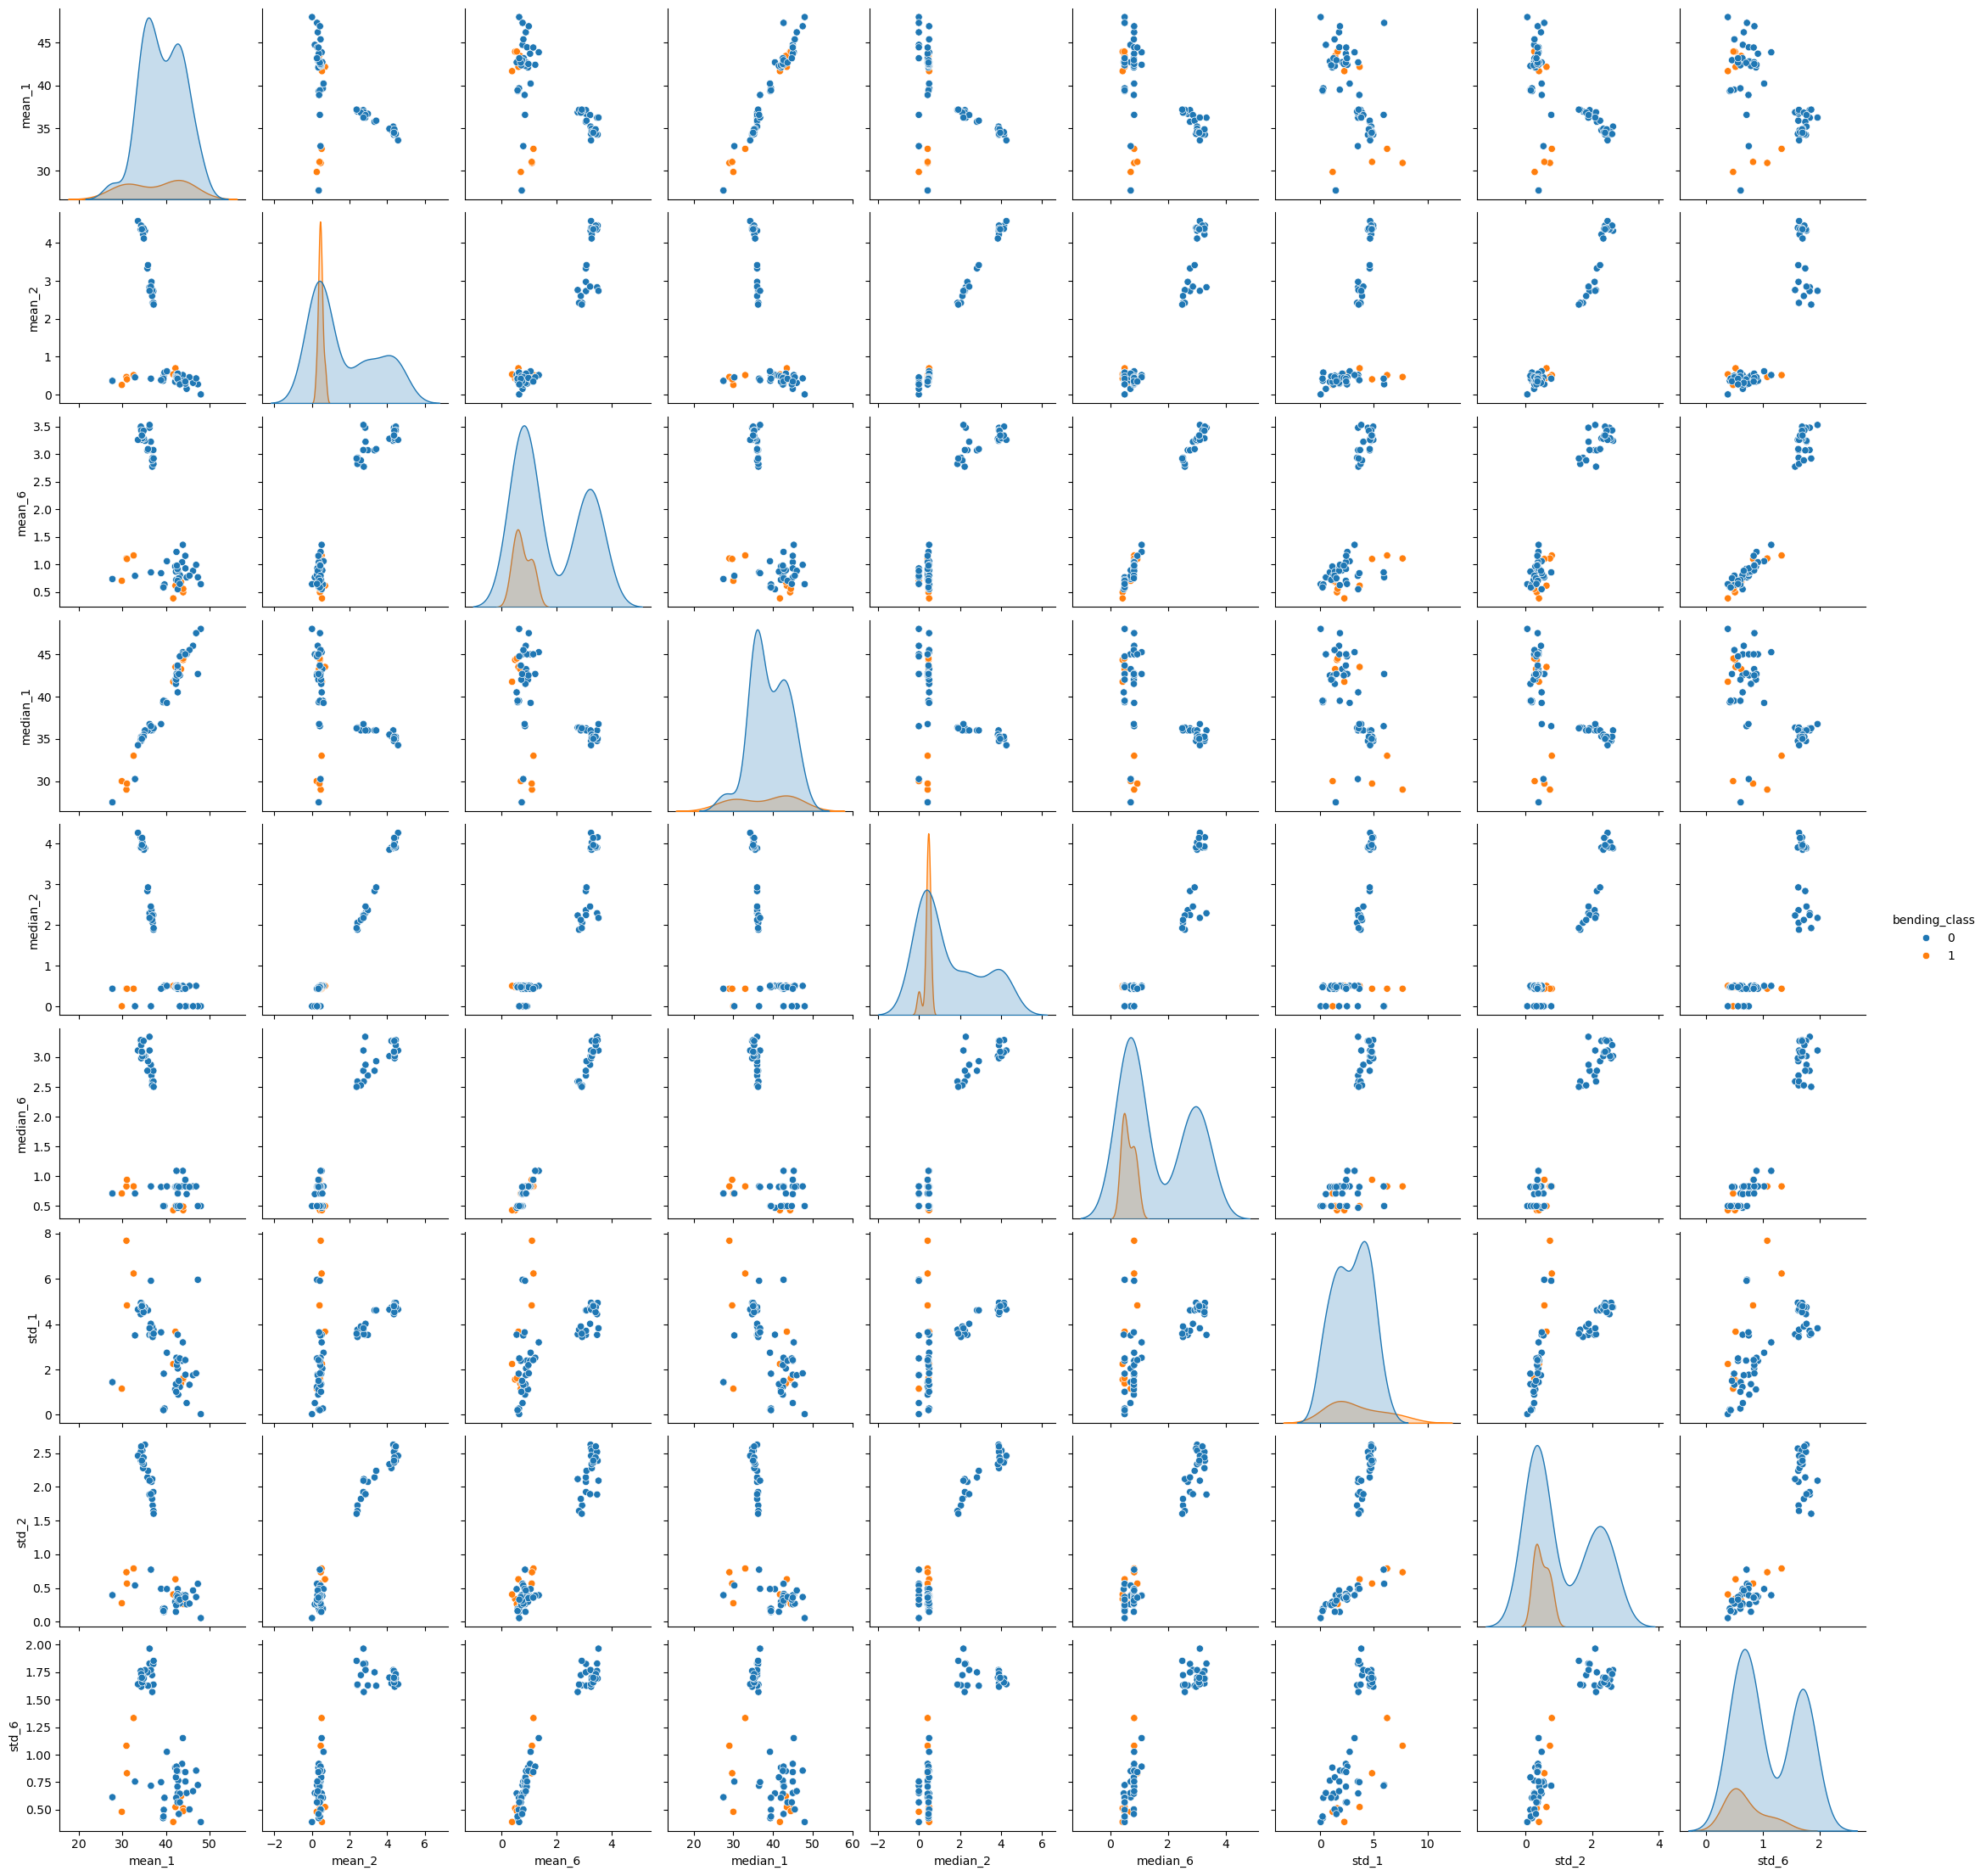

In [11]:
selected_features = ['mean', 'median', 'std'] 
selected_td_features = [f'{feature}_{i}' for feature in selected_features for i in [1,2,6]]
scatter_df = training_df.loc[:, selected_td_features]
scatter_df['bending_class'] = np.where(scatter_df.index < 10, 1, 0)
sns.pairplot(scatter_df, hue="bending_class", diag_kind="kde")

ii. Splitted Plots

In [12]:
def split_col(df, instance, col):
    mid_index = int(df.shape[0] / 2)
    first_half = df[(instance, col)].iloc[:mid_index].reset_index(drop=True)
    second_half = df[(instance, col)].iloc[mid_index:].reset_index(drop=True)
    return first_half, second_half

split_columns = {}

for instance in training_col:  
    for col in train_set[instance]:
        first_half, second_half = split_col(train_set, instance, col)
        split_columns[(f'{instance}_first_half', col)] = first_half
        split_columns[(f'{instance}_second_half', col)] = second_half

split_train_set = pd.DataFrame(split_columns)
split_train_set.columns = pd.MultiIndex.from_tuples(split_train_set.columns)

# Sort the columns by their top-level to group 'first_half' and 'second_half' under each top-level instance
split_train_set = split_train_set.sort_index(axis=1, level=0)


print('Original Train Shape:', train_set.shape)
print('Split Train Shape:', split_train_set.shape)

Original Train Shape: (480, 414)
Split Train Shape: (240, 828)


In [13]:
split_train_set

bending1_dataset3_first_half                                          \
                       avg_rss12 avg_rss13 avg_rss23 var_rss12 var_rss13   
0                          42.00     21.25     30.00      0.71      0.43   
1                          41.50     20.25     31.25      0.50      1.48   
2                          41.50     14.25     33.00      0.50      1.92   
3                          40.75     15.75     33.00      0.83      0.43   
4                          40.00     20.00     32.75      0.71      2.74   
..                           ...       ...       ...       ...       ...   
235                        45.50     24.00     36.00      0.50      0.00   
236                        45.25     23.25     36.00      0.43      0.83   
237                        45.00     20.75     36.00      0.00      1.09   
238                        44.25     18.00     36.00      0.83      0.00   
239                        43.25     18.00     35.25      0.83      0.00   

              bending1_dataset3_second_half                                \
    var_rss23                     avg_rss12 avg_rss13 avg_rss23 var_rss12   
0        0.00                         43.33     18.00     35.67      0.94   
1        1.09                         44.20     19.75     35.40      0.75   
2        0.00                         45.00     21.75     35.00      0.00   
3        0.00                         45.00     23.33     36.00      0.00   
4        0.43                         45.00     24.00     36.00      0.00   
..        ...                           ...       ...       ...       ...   
235      0.00                         42.50     20.00     36.00      0.50   
236      0.00                         42.67     21.00     36.33      0.47   
237      0.00                         44.33     21.00     36.33      0.94   
238      0.00                         45.25     26.75     36.00      0.43   
239      1.30                         47.25     29.75     35.25      0.83   

     ... walking_dataset9_first_half                                \
     ...                   avg_rss23 var_rss12 var_rss13 var_rss23   
0    ...                       18.00      5.76      4.36      2.12   
1    ...                       14.75      5.07      3.20      1.79   
2    ...                       20.50      2.60      4.74      2.87   
3    ...                       14.25      5.36      6.22      3.77   
4    ...                       11.50      3.77      6.63      2.69   
..   ...                         ...       ...       ...       ...   
235  ...                       14.50      4.26      3.63      2.60   
236  ...                       13.50      3.27      1.79      5.59   
237  ...                       13.00      7.98      4.44      6.52   
238  ...                       15.50      4.06      3.24      5.41   
239  ...                       15.50      3.20      2.68      3.04   

    walking_dataset9_second_half                                          \
                       avg_rss12 avg_rss13 avg_rss23 var_rss12 var_rss13   
0                          37.50     20.75     11.00      1.50      0.43   
1                          30.75     16.50     14.33      6.30      3.35   
2                          26.25     19.00     14.75      3.34      0.71   
3                          37.00     16.33     15.33      8.92      5.25   
4                          35.50     19.75     21.75      5.55      3.49   
..                           ...       ...       ...       ...       ...   
235                        31.50     12.50     14.25      1.66      3.20   
236                        27.33     11.33     20.00      1.25      0.94   
237                        37.80     14.20     17.25      7.68      2.48   
238                        33.75     15.75     16.50      1.30      5.21   
239                        32.67     18.67     14.00      3.09      0.47   

               
    var_rss23  
0        2.35  
1        4.78  
2        1.09  
3        5.79  
4        1.30  
.

In [14]:
split_train_feature_df = compute_features(split_train_set[f'{training_col[0]}_first_half'])
for instance in training_col[1:]:
    new_row = compute_features(split_train_set[f'{instance}_second_half'])
    split_train_feature_df = pd.concat([split_train_feature_df, new_row])
    new_row = compute_features(split_train_set[f'{instance}_first_half'])
    split_train_feature_df = pd.concat([split_train_feature_df, new_row])
last_row = compute_features(split_train_set[f'{training_col[-1]}_second_half'])
split_train_feature_df = pd.concat([split_train_feature_df, last_row])

split_train_feature_df = split_train_feature_df.reset_index(drop=True)  
split_train_feature_df.index = split_train_feature_df.index + 1  
split_train_feature_df.index.name = 'Instance'  
split_train_feature_df.shape

(138, 42)

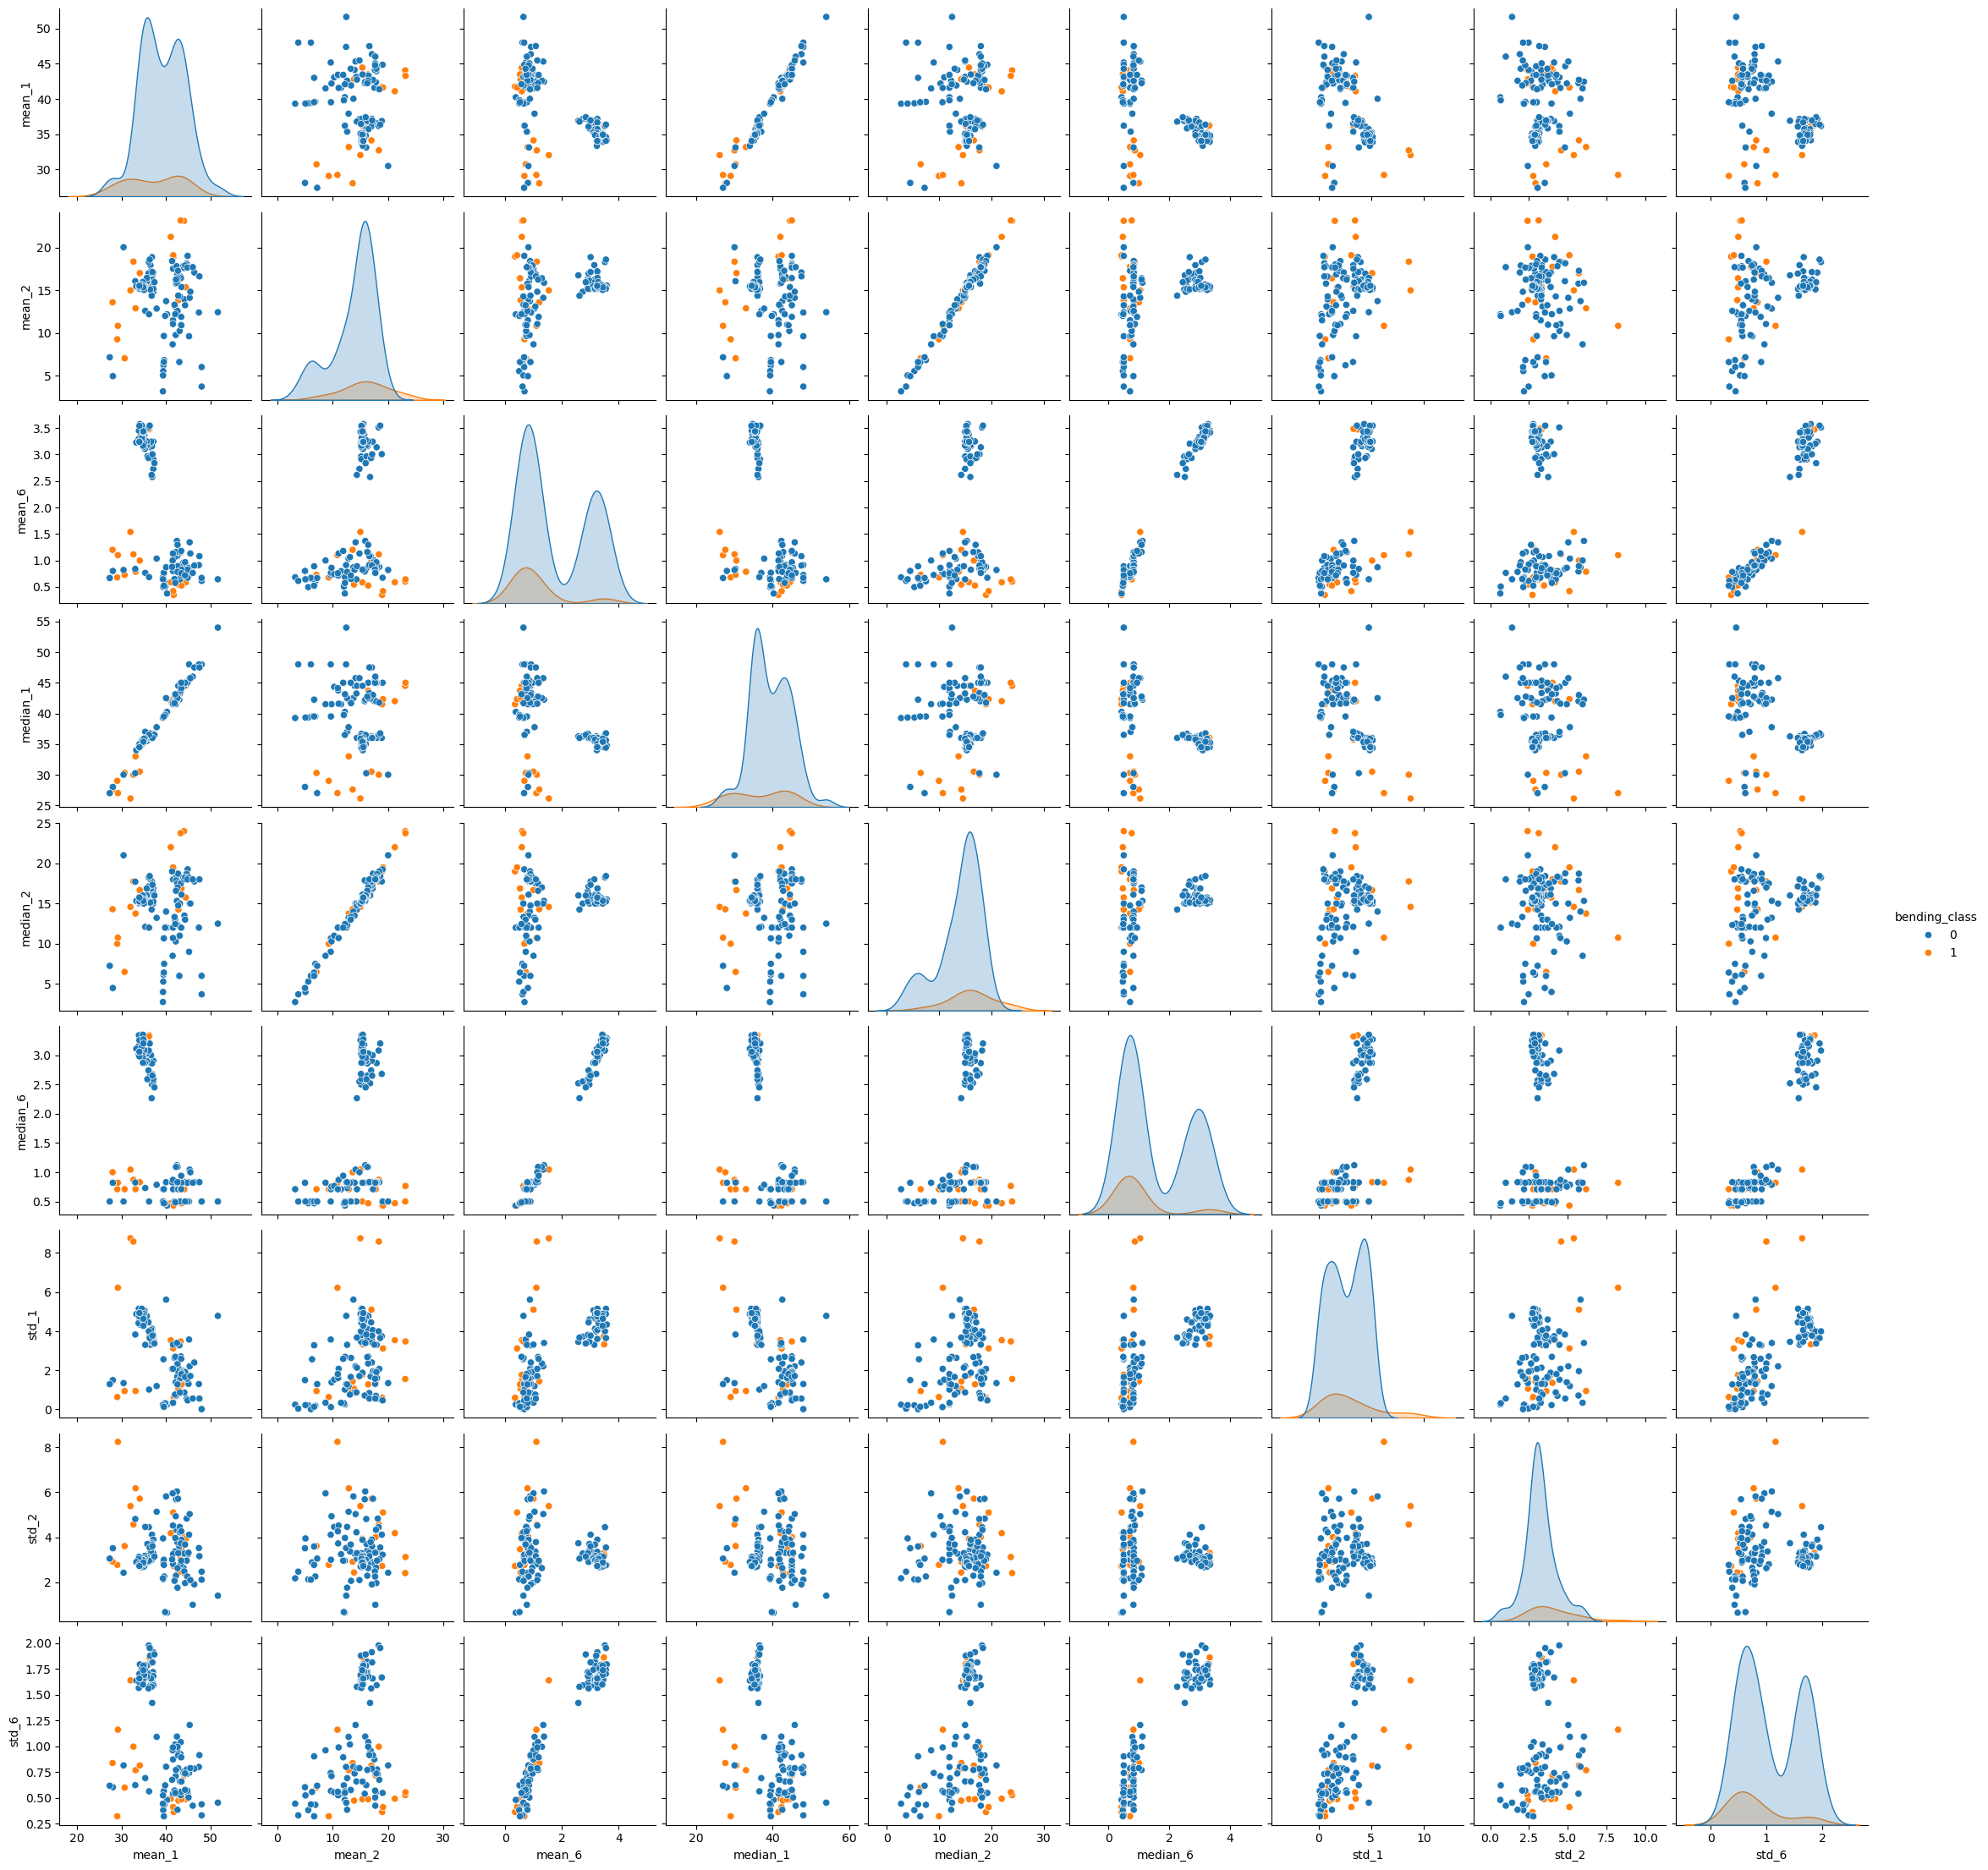

In [15]:
selected_td_features = [f'{feature}_{i}' for feature in selected_features for i in [1,2,6]]
scatter_df = split_train_feature_df.loc[:, selected_td_features]
scatter_df['bending_class'] = np.where(scatter_df.index < 20, 1, 0)
sns.pairplot(scatter_df, hue="bending_class", diag_kind="kde")

By splitting the time series and calculating features based on these smaller segments, we can capture more localized patterns and variations that might otherwise be diluted in the full-length series. This could lead to enhanced feature diversity and better separation between classes which may help the model's ability to distinguish between them. 

iii. Time Series Segments

In [16]:
def segment_time_series(df, instance, l):
    segment_size = math.ceil(df.shape[0] / l)
    new_cols = {}
    for col in df[instance]:
        for i in range(l):
            start_index = i * segment_size
            if i == l-1: 
                end_index = df.shape[0]
            else:
                end_index = start_index + segment_size
            segment = df[(instance, col)][start_index:end_index].reset_index(drop=True)
            if (i == l-1) & (len(segment) != segment_size):
                segment = segment.reindex(range(segment_size), fill_value=np.nan)
            new_cols[f'{col}_segment_{i+1}'] = segment.tolist()
    segmented_df = pd.DataFrame(new_cols)
    instance_multi_index = [f'{instance}'] * len(segmented_df.columns)
    segmented_df.columns = pd.MultiIndex.from_arrays([instance_multi_index, segmented_df.columns])
    return segmented_df

def calculate_features(df, columns, l):  
    segmented_df = segment_time_series(df, columns[0], l)
    for instance in columns[1:]:
        instance_segmented = segment_time_series(df, instance, l)
        segmented_df = pd.concat((segmented_df, instance_segmented), axis=1)
    segmented_df = segmented_df.reset_index(drop=True)  

    segmented_features_df = compute_features(segmented_df[columns[0]])
    for instance in columns[1:]:
        new_row = compute_features(segmented_df[instance])
        segmented_features_df = pd.concat([segmented_features_df, new_row])
    
    segmented_features_df = segmented_features_df.reset_index(drop=True)  
    segmented_features_df.index = segmented_features_df.index + 1  
    segmented_features_df.index.name = 'Instance'  
    
    return segmented_features_df

def performance_summary(y_true, y_pred, y_pred_prob, multi_class=False):

    if multi_class == True:
        auroc = roc_auc_score(y_true, y_pred_prob, multi_class='ovr')
    else: 
        auroc = roc_auc_score(y_true, y_pred_prob)
    accuracy = accuracy_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)

    if multi_class == False:

        fig, axis = plt.subplots(1, 2, figsize=(10, 5))
        
        print('ROC AUC:', auroc)
        print('Accuracy:', accuracy)
        disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
        disp.plot(ax=axis[0])
        axis[0].set_title("Confusion Matrix")
        
        fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
        axis[1].plot(fpr, tpr, color='darkorange', lw=6, label=f'ROC Curve (area={auroc:.4f})')
        axis[1].plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
        axis[1].set_xlabel('False Positive Rate')
        axis[1].set_ylabel('True Positive Rate')
        axis[1].set_title('ROC Curve')
        axis[1].legend(loc='lower right')

    else:
        print('ROC AUC:', auroc)
        print('Accuracy:', accuracy)
        disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
        disp.plot()
        plt.title("Confusion Matrix")

    plt.tight_layout()
    plt.show()

In [17]:
result_summary = {'l': [], 'Median Number of Selected Features': [], 'Mean Accuracy': [], 'Mean F1 Score': [], 'Mean ROC AUC': []}

for l in range(1,21):
    X_train = calculate_features(train_set, training_col, l)
    split_features = X_train.columns
    y_train = np.zeros(69, dtype=int)
    y_train[:9] = 1
    
    model = LogisticRegression(max_iter=10000, random_state=24)
    cross_val = StratifiedKFold(5, shuffle=True, random_state=24)

    f1_scores = []
    accuracy_scores = []
    roc_scores = []
    num_features_list = []

    for train_index, val_index in cross_val.split(X_train, y_train):
        
        X_subtraining = X_train.iloc[train_index, :]
        X_subtesting = X_train.iloc[val_index, :]
        y_subtraining = y_train[train_index]
        y_subtesting = y_train[val_index]
        
        feature_elim = RFECV(estimator=model, cv=StratifiedKFold(5, shuffle=True, random_state=25), scoring='f1')
        feature_elim.fit(X_subtraining, y_subtraining)
        X_subtraining_selected = feature_elim.transform(X_subtraining)
        X_subtesting_selected = feature_elim.transform(X_subtesting)

        model.fit(X_subtraining_selected, y_subtraining)
        y_pred = model.predict(X_subtesting_selected)
        y_pred_prob = model.predict_proba(X_subtesting_selected)[:, 1]
        
        f1 = f1_score(y_subtesting, y_pred)
        accuracy = accuracy_score(y_subtesting, y_pred)
        roc_score = roc_auc_score(y_subtesting, y_pred_prob)
        num_features = feature_elim.n_features_
        f1_scores.append(f1)
        accuracy_scores.append(accuracy)
        roc_scores.append(roc_score)
        
        num_features_list.append(num_features)

    mean_f1 = np.mean(f1_scores)
    mean_accuracy = np.mean(accuracy_scores)
    mean_roc_score = np.mean(roc_scores)
    median_num_features = int(np.median(num_features_list))

    result_summary['l'].append(l)
    result_summary['Median Number of Selected Features'].append(median_num_features)
    result_summary['Mean Accuracy'].append(mean_accuracy)
    result_summary['Mean F1 Score'].append(mean_f1)
    result_summary['Mean ROC AUC'].append(mean_roc_score)

result_df = pd.DataFrame(result_summary)
result_df

,l,Median Number of Selected Features,Mean Accuracy,Mean F1 Score,Mean ROC AUC
0,1,3,0.928571,0.533333,0.795833
1,2,7,0.914286,0.533333,0.933333
2,3,17,0.900000,0.493333,0.925000
3,4,10,0.885714,0.466667,0.966667
4,5,8,0.900000,0.600000,0.975000
5,6,22,0.928571,0.660000,0.983333
6,7,14,0.928571,0.626667,0.991667
7,8,34,0.914286,0.560000,0.983333
8,9,31,0.885714,0.360000,0.966667
9,10,47,0.928571,0.626667,0.916667


The right way to perform cross-validation in this problem is to perform the feature selection on each of the k-1 folds in the cross-validation procedure where the optimal features are selected based on the subtraining data of each fold. The wrong way of performing cross-validation is to select the features prior to splitting the data into k folds and then perform cross-validation after already selecting the features. 

iv. Confusion Matrix

ROC AUC: 1.0
Accuracy: 1.0


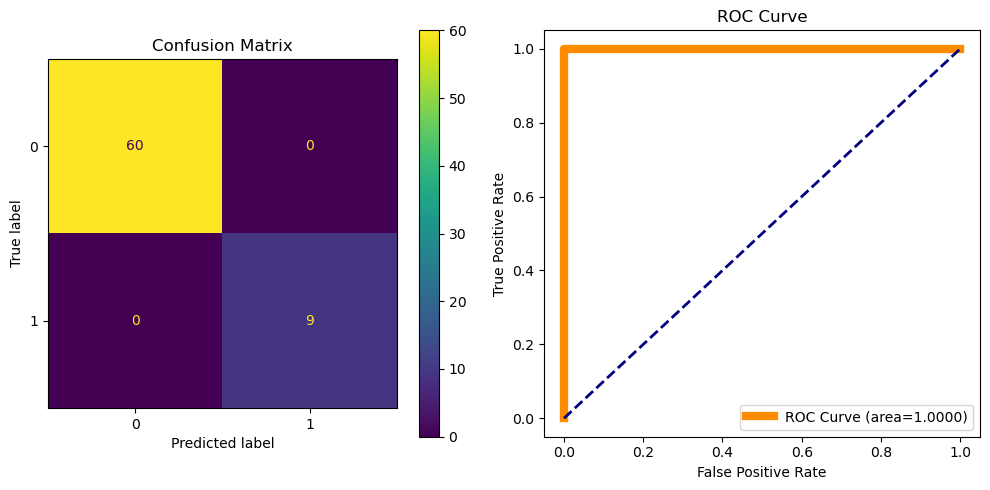

In [18]:
X_train_split = calculate_features(train_set, training_col, 19)
y_train = np.zeros(69, dtype=int)
y_train[:9] = 1

model = LogisticRegression(max_iter=10000, random_state=24)
rfe = RFE(model, n_features_to_select=11)
X_train_selected = rfe.fit_transform(X_train_split, y_train)

selected_features = rfe.support_  
feature_names = X_train_split.columns  
selected_feature_names = feature_names[selected_features]

model.fit(X_train_selected, y_train)
coefficients = model.coef_[0]
y_train_pred = model.predict(X_train_selected)
y_train_pred_prob = model.predict_proba(X_train_selected)[:, 1]

performance_summary(y_train, y_train_pred, y_train_pred_prob)

In [19]:
X_matrix = np.hstack([np.ones((X_train_selected.shape[0], 1)), X_train_selected])
beta = np.concatenate([model.intercept_, model.coef_.flatten()])

p = 1 / (1 + np.exp(-X_matrix @ beta))
W = np.diag(p * (1 - p))
I = X_matrix.T @ W @ X_matrix

Var_beta = np.linalg.pinv(I) 
SE_beta = np.sqrt(np.diag(Var_beta))
z_stats = beta / SE_beta
p_values = 2 * (1 - norm.cdf(np.abs(z_stats)))

summary_df = pd.DataFrame({'Feature': selected_feature_names, 'Coefficient Value': beta[1:], 'p-Value': p_values[1:]})
summary_df

,Feature,Coefficient Value,p-Value
0,max_11,-0.170241,0.980677
1,3rd_quartile_11,-0.174465,0.972747
2,max_13,-0.160001,0.972834
3,max_55,-0.144264,0.928325
4,min_78,0.158856,0.929283
5,min_79,0.192869,0.943725
6,mean_79,0.160705,0.994105
7,median_79,0.146718,0.992655
8,1st_quartile_79,0.204353,0.972391
9,min_82,0.162318,0.907922


Interestingly, I am getting p-values that are close to 1. This could be because of multicollinearity amongst the features which is why I was also getting an error indicating that the Hessian matrix was singular when using the 'statsmodels' package. We can also see from the performance metrics on the training data that the classes are perfectly separable which could be one of the root causes of this phenomenon. 

v. Test Classifier

ROC AUC: 1.0
Accuracy: 0.9473684210526315


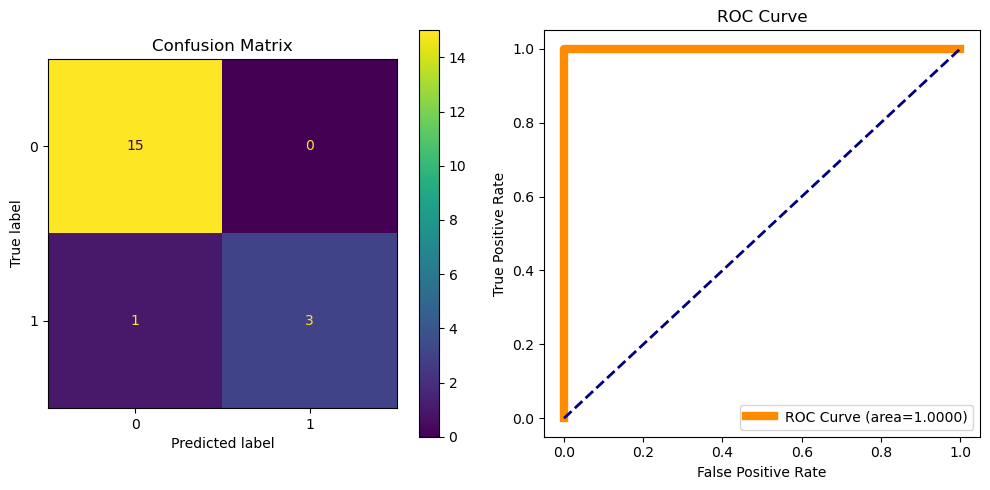

In [20]:
X_test_split = calculate_features(test_set, test_col, 19)
y_test = np.zeros(19, dtype=int)
y_test[:4] = 1

X_test_selected = rfe.transform(X_test_split)
y_test_pred = model.predict(X_test_selected)
y_test_pred_prob = model.predict_proba(X_test_selected)[:, 1]

performance_summary(y_test, y_test_pred, y_test_pred_prob)

TRAIN PERFORMANCE
ROC AUC: 1.0
Accuracy: 1.0


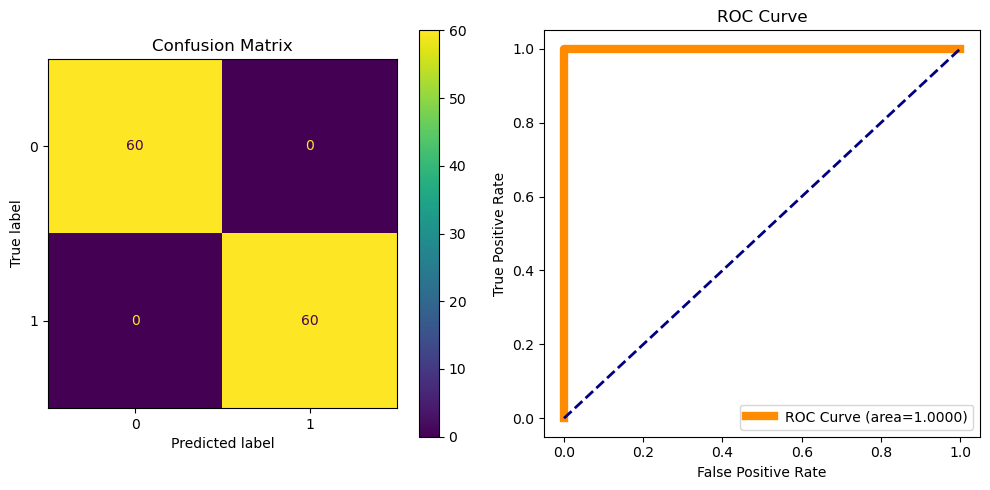

TEST PERFORMANCE
ROC AUC: 1.0
Accuracy: 0.9473684210526315


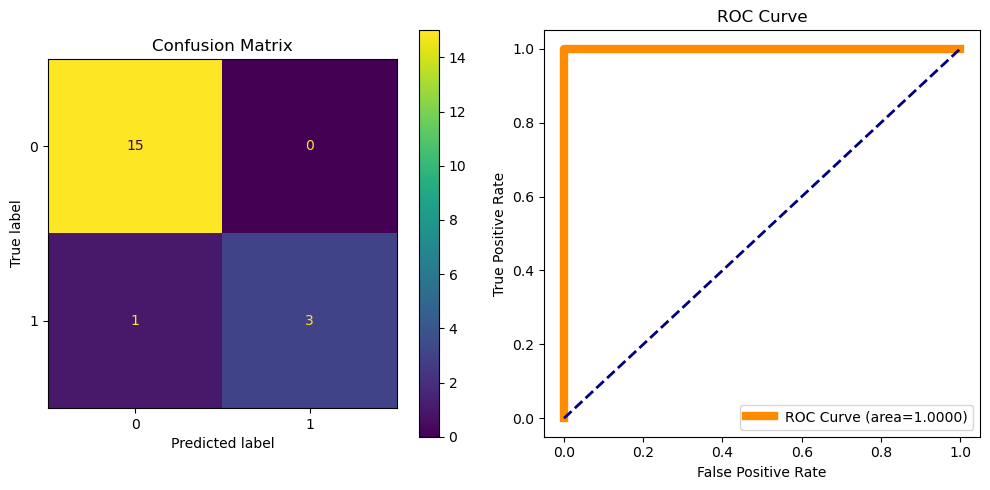

In [21]:
smote = SMOTE(random_state=24)
model = LogisticRegression(max_iter=10000, random_state=24)
rfe = RFE(model, n_features_to_select=11)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train)
model.fit(X_train_resampled, y_train_resampled)

y_train_pred = model.predict(X_train_resampled)
y_train_pred_prob = model.predict_proba(X_train_resampled)[:, 1]

y_test_pred = model.predict(X_test_selected)
y_test_pred_prob = model.predict_proba(X_test_selected)[:, 1]

train_auroc = roc_auc_score(y_train_resampled, y_train_pred_prob)
train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
train_conf_matrix = confusion_matrix(y_train_resampled, y_train_pred)

test_auroc = roc_auc_score(y_test, y_test_pred_prob, multi_class='ovr')
test_accuracy = accuracy_score(y_test, y_test_pred)
test_conf_matrix = confusion_matrix(y_test, y_test_pred)

print('TRAIN PERFORMANCE')
performance_summary(y_train_resampled, y_train_pred, y_train_pred_prob)
print('TEST PERFORMANCE')
performance_summary(y_test, y_test_pred, y_test_pred_prob)

We can see that the rebalancing of the data does not improve the model's performance, however, this could be because we do not have a large testing set to rigorously assess if this new model is an improvement upon the raw, unbalanced model. Perhaps with a larger testing set we can more accurately assess the quality of the balanced model in comparison to the raw model. 

# Binary Classification Using L1-penalized logistic regression

i. Time Series Segments

In [22]:
result_summary = {'l': [], 'Median Best C': [], 'Median Number of Selected Features': [], 'Mean Accuracy': [], 'Mean F1 Score': [], 'Mean ROC AUC': []}

for l in range(1,21):
    X_train = calculate_features(train_set, training_col, l)
    split_features = X_train.columns
    
    model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=10000, random_state=24)
    cross_val = StratifiedKFold(5, shuffle=True, random_state=24)

    f1_scores = []
    accuracy_scores = []
    roc_scores = []
    best_c_list = []
    num_features_list = []

    for train_index, val_index in cross_val.split(X_train, y_train):
        
        X_subtraining = X_train.iloc[train_index, :]
        X_subtesting = X_train.iloc[val_index, :]
        y_subtraining = y_train[train_index]
        y_subtesting = y_train[val_index]
        
        param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
        grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=25), scoring='f1')
        grid.fit(X_subtraining, y_subtraining)
        best_c = grid.best_params_['C']
        best_c_list.append(best_c)

        log_reg = LogisticRegression(penalty='l1', solver='liblinear', C=best_c, max_iter=10000, random_state=24)
        log_reg.fit(X_subtraining, y_subtraining)
        y_pred = log_reg.predict(X_subtesting)
        y_pred_prob = log_reg.predict_proba(X_subtesting)[:, 1]
        
        f1 = f1_score(y_subtesting, y_pred)
        accuracy = accuracy_score(y_subtesting, y_pred)
        roc_score = roc_auc_score(y_subtesting, y_pred_prob)
        coefficients = log_reg.coef_[0]
        num_features = np.sum(coefficients != 0)
        
        f1_scores.append(f1)
        accuracy_scores.append(accuracy)
        roc_scores.append(roc_score)
        num_features_list.append(num_features)

    mean_f1 = np.mean(f1_scores)
    mean_accuracy = np.mean(accuracy_scores)
    mean_roc_score = np.mean(roc_scores)
    median_best_c = int(np.median(best_c_list))
    median_num_features = int(np.median(num_features_list))

    result_summary['l'].append(l)
    result_summary['Median Number of Selected Features'].append(median_num_features)
    result_summary['Median Best C'].append(median_best_c)
    result_summary['Mean Accuracy'].append(mean_accuracy)
    result_summary['Mean F1 Score'].append(mean_f1)
    result_summary['Mean ROC AUC'].append(mean_roc_score)

result_df = pd.DataFrame(result_summary)
result_df

,l,Median Best C,Median Number of Selected Features,Mean Accuracy,Mean F1 Score,Mean ROC AUC
0,1,1,7,0.942857,0.733333,0.966667
1,2,100,18,0.914286,0.560000,0.900000
2,3,1,13,0.928571,0.600000,0.925000
3,4,10,26,0.928571,0.600000,0.966667
4,5,10,28,0.900000,0.533333,0.941667
5,6,10,34,0.900000,0.533333,0.908333
6,7,100,100,0.928571,0.560000,0.966667
7,8,10,41,0.914286,0.560000,0.966667
8,9,1,11,0.928571,0.600000,0.966667
9,10,100,87,0.900000,0.493333,0.983333


When using the L1-regularization we can see that as we increase the number of time series splits we actually get worse performance in terms of mean CV accuracy. However, the mean ROC AUC score actually increases as we increase the splits which is quite an interesting tradeoff.  

ii. Comparison

TRAIN PERFORMANCE
ROC AUC: 1.0
Accuracy: 1.0


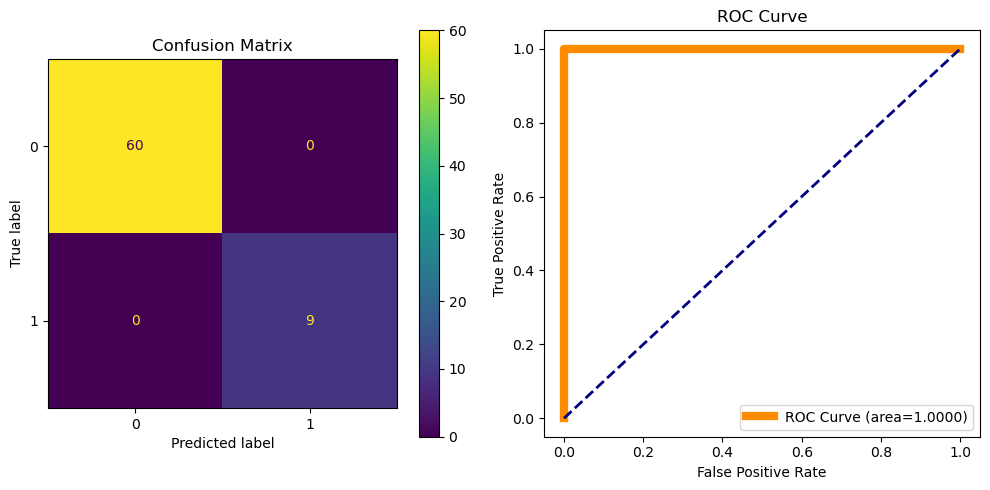

TEST PERFORMANCE
ROC AUC: 1.0
Accuracy: 1.0


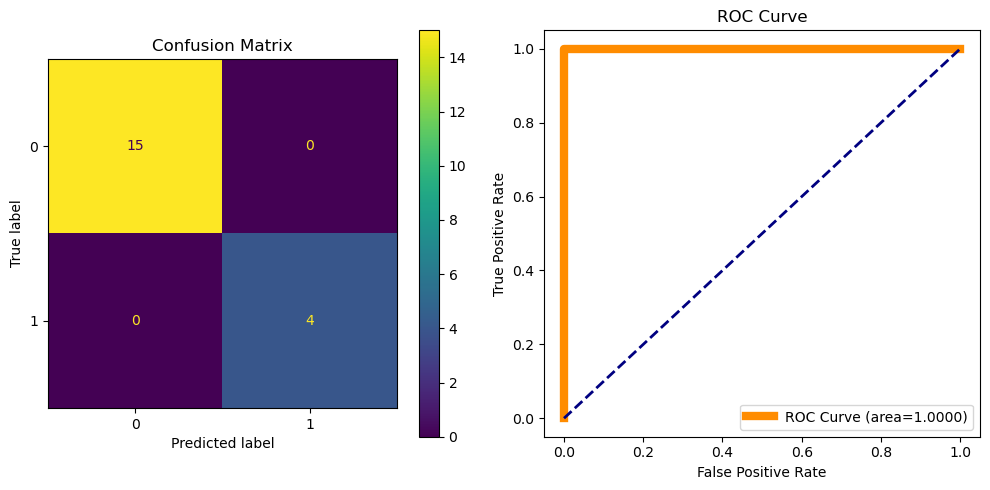

In [23]:
X_train_split = calculate_features(train_set, training_col, 1)
X_test_split = calculate_features(test_set, test_col, 1)

model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=10000, random_state=24)
model.fit(X_train_split, y_train)

y_train_pred = model.predict(X_train_split)
y_train_pred_prob = model.predict_proba(X_train_split)[:, 1]

y_test_pred = model.predict(X_test_split)
y_test_pred_prob = model.predict_proba(X_test_split)[:, 1]

print('TRAIN PERFORMANCE')
performance_summary(y_train, y_train_pred, y_train_pred_prob)
print('TEST PERFORMANCE')
performance_summary(y_test, y_test_pred, y_test_pred_prob)

Performing variable selection with L1-regularization is not only more computationally efficient then using recursive feature elimination (RFE), but it is also easier to implement because it will naturally prune the features. Furthermore, we can see from the results above that the l1-penalized model actually performs better on the test set. 

# Multi-class Classification (The Realistic Case)

i. Time Series Segments

In [24]:
y_train_multi = np.zeros(69, dtype=int)
y_train_multi[:9] = 1
y_train_multi[9:21] = 2
y_train_multi[21:33] = 3
y_train_multi[33:45] = 4
y_train_multi[45:57] = 5
y_train_multi[57:69] = 6

y_test_multi = np.zeros(19, dtype=int)
y_test_multi[:4] = 1
y_test_multi[4:7] = 2
y_test_multi[7:10] = 3
y_test_multi[10:13] = 4
y_test_multi[13:16] = 5
y_test_multi[16:19] = 6

In [25]:
result_summary = {'l': [], 'Median Best C': [], 'Median Number of Selected Features': [], 'Mean Accuracy': [], 'Mean ROC AUC': []}

for l in range(1,21):
    X_train = calculate_features(train_set, training_col, l)
    split_features = X_train.columns
    y_train = np.zeros(69, dtype=int)
    y_train[:9] = 1
    
    model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=10000, random_state=24)
    cross_val = StratifiedKFold(5, shuffle=True, random_state=22)

    f1_scores = []
    accuracy_scores = []
    roc_scores = []
    best_c_list = []
    num_features_list = []

    for train_index, val_index in cross_val.split(X_train, y_train):
        
        X_subtraining = X_train.iloc[train_index, :]
        X_subtesting = X_train.iloc[val_index, :]
        y_subtraining = y_train_multi[train_index]
        y_subtesting = y_train_multi[val_index]
        
        param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
        grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=25), scoring='accuracy')
        grid.fit(X_subtraining, y_subtraining)
        best_c = grid.best_params_['C']
        best_c_list.append(best_c)

        log_reg = LogisticRegression(penalty='l1', solver='liblinear', C=best_c, max_iter=10000, random_state=24)
        log_reg.fit(X_subtraining, y_subtraining)
        y_pred = log_reg.predict(X_subtesting)
        y_pred_prob = log_reg.predict_proba(X_subtesting)
        
        accuracy = accuracy_score(y_subtesting, y_pred)
        roc_score = roc_auc_score(y_subtesting, y_pred_prob, multi_class='ovr')
        coefficients = log_reg.coef_[0]
        num_features = np.sum(coefficients != 0)
        
        accuracy_scores.append(accuracy)
        roc_scores.append(roc_score)
        num_features_list.append(num_features)

    mean_accuracy = np.mean(accuracy_scores)
    mean_roc_score = np.mean(roc_scores)
    median_best_c = int(np.median(best_c_list))
    median_num_features = int(np.median(num_features_list))

    result_summary['l'].append(l)
    result_summary['Median Number of Selected Features'].append(median_num_features)
    result_summary['Median Best C'].append(median_best_c)
    result_summary['Mean Accuracy'].append(mean_accuracy)
    result_summary['Mean ROC AUC'].append(mean_roc_score)

result_df = pd.DataFrame(result_summary)
result_df

,l,Median Best C,Median Number of Selected Features,Mean Accuracy,Mean ROC AUC
0,1,1,9,0.898901,0.991695
1,2,100,29,0.871429,0.964841
2,3,100,42,0.812088,0.976282
3,4,100,63,0.783516,0.975907
4,5,100,72,0.797802,0.970865
5,6,100,83,0.682418,0.950235
6,7,100,103,0.813187,0.980870
7,8,100,115,0.710989,0.941323
8,9,10,49,0.680220,0.946803
9,10,100,81,0.756044,0.962848


For multiclassification, it is clear from the results above that splitting the data yields worse performance and makes the model much more complex. Thus, using the raw time series features is best in this case. 

Number of Selected Features: 7
TRAIN PERFORMANCE
ROC AUC: 1.0
Accuracy: 0.9855072463768116


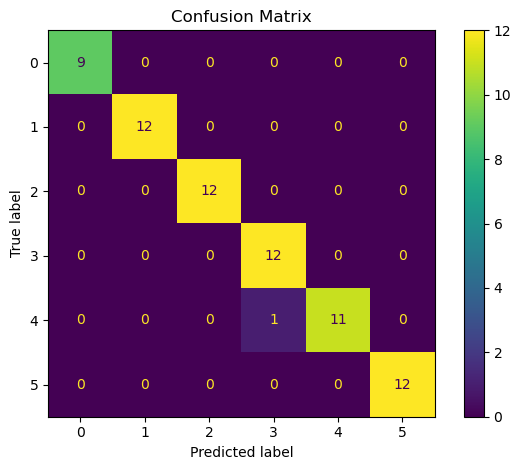

TEST PERFORMANCE
ROC AUC: 0.9583333333333334
Accuracy: 0.8421052631578947


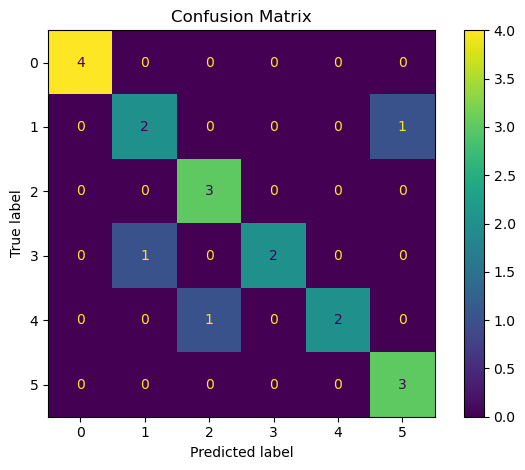

In [26]:
X_train_split = calculate_features(train_set, training_col, 1)
X_test_split = calculate_features(test_set, test_col, 1)

model = LogisticRegression(penalty='l1', solver='liblinear', C=1, max_iter=10000, random_state=24)
model.fit(X_train_split, y_train_multi)

coefficients = model.coef_[0]
num_features = np.sum(coefficients != 0)
print('Number of Selected Features:', num_features)

y_train_pred = model.predict(X_train_split)
y_train_pred_prob = model.predict_proba(X_train_split)

y_test_pred = model.predict(X_test_split)
y_test_pred_prob = model.predict_proba(X_test_split)

print('TRAIN PERFORMANCE')
performance_summary(y_train_multi, y_train_pred, y_train_pred_prob, multi_class=True)
print('TEST PERFORMANCE')
performance_summary(y_test_multi, y_test_pred, y_test_pred_prob, multi_class=True)

Performance on multiclassification is not as good as binary classification, but this is to be expected as multiclassification is a more complex task. 

ii. Naive Bayes

In [27]:
def find_best_l_naive_bayes(nb_model):
    result_summary = {'l': [], 'Mean Accuracy': [], 'Mean ROC AUC': []}
    
    for l in range(1,21):
        X_train = calculate_features(train_set, training_col, l)
        split_features = X_train.columns
        y_train = np.zeros(69, dtype=int)
        y_train[:9] = 1
        
        cross_val = StratifiedKFold(5, shuffle=True, random_state=22)
    
        accuracy_scores = []
        roc_scores = []
    
        for train_index, val_index in cross_val.split(X_train, y_train):
            
            X_subtraining = X_train.iloc[train_index, :]
            X_subtesting = X_train.iloc[val_index, :]
            y_subtraining = y_train_multi[train_index]
            y_subtesting = y_train_multi[val_index]
            
            nb_model.fit(X_subtraining, y_subtraining)
            y_pred = nb_model.predict(X_subtesting)
            y_pred_prob = nb_model.predict_proba(X_subtesting)
            
            accuracy = accuracy_score(y_subtesting, y_pred)
            roc_score = roc_auc_score(y_subtesting, y_pred_prob, multi_class='ovr')
            
            accuracy_scores.append(accuracy)
            roc_scores.append(roc_score)
    
        mean_accuracy = np.mean(accuracy_scores)
        mean_roc_score = np.mean(roc_scores)
    
        result_summary['l'].append(l)
        result_summary['Mean Accuracy'].append(mean_accuracy)
        result_summary['Mean ROC AUC'].append(mean_roc_score)
    
    result_df = pd.DataFrame(result_summary)
    return result_df
    

def evaluate_nb_model(nb_model, l):
    X_train_split = calculate_features(train_set, training_col, l)
    X_test_split = calculate_features(test_set, test_col, l)
    
    nb_model.fit(X_train_split, y_train_multi)
    
    y_train_pred = nb_model.predict(X_train_split)
    y_train_pred_prob = nb_model.predict_proba(X_train_split)
    
    y_test_pred = nb_model.predict(X_test_split)
    y_test_pred_prob = nb_model.predict_proba(X_test_split)
    
    train_auroc = roc_auc_score(y_train_multi, y_train_pred_prob, multi_class='ovr')
    train_accuracy = accuracy_score(y_train_multi, y_train_pred)
    train_conf_matrix = confusion_matrix(y_train_multi, y_train_pred)
    
    test_auroc = roc_auc_score(y_test_multi, y_test_pred_prob, multi_class='ovr')
    test_accuracy = accuracy_score(y_test_multi, y_test_pred)
    test_conf_matrix = confusion_matrix(y_test_multi, y_test_pred)

    print('TRAIN PERFORMANCE')
    performance_summary(y_train_multi, y_train_pred, y_train_pred_prob, multi_class=True)
    
    print('TEST PERFORMANCE')
    performance_summary(y_test_multi, y_test_pred, y_test_pred_prob, multi_class=True)

In [28]:
print("Best L Search for GaussianNB")
gauss_nb_model = GaussianNB()
find_best_l_naive_bayes(gauss_nb_model)

Best L Search for GaussianNB


,l,Mean Accuracy,Mean ROC AUC
0,1,0.823077,0.961111
1,2,0.824176,0.937003
2,3,0.709890,0.889197
3,4,0.752747,0.916816
4,5,0.767033,0.891935
5,6,0.693407,0.897654
6,7,0.709890,0.876276
7,8,0.753846,0.914846
8,9,0.607692,0.789958
9,10,0.665934,0.834359


Again, splitting the time series seems to only diminish performance. 

TRAIN PERFORMANCE
ROC AUC: 0.9993827160493828
Accuracy: 0.9855072463768116


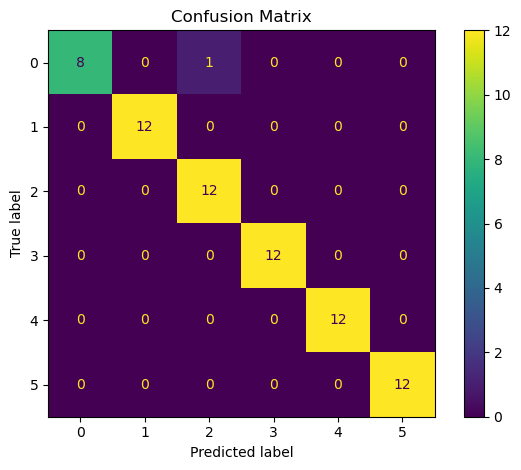

TEST PERFORMANCE
ROC AUC: 0.9614583333333333
Accuracy: 0.8947368421052632


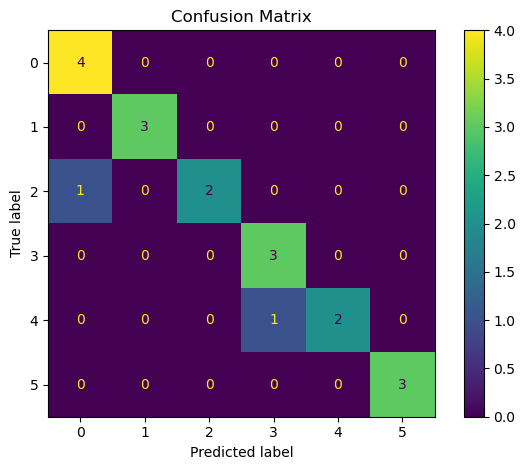

In [29]:
evaluate_nb_model(gauss_nb_model, 1)

In [30]:
print("Best L Search for MultinomialNB")
multi_nb_model = MultinomialNB()
find_best_l_naive_bayes(multi_nb_model)

Best L Search for MultinomialNB


,l,Mean Accuracy,Mean ROC AUC
0,1,0.853846,0.982187
1,2,0.826374,0.975484
2,3,0.827473,0.971419
3,4,0.783516,0.977325
4,5,0.797802,0.978677
5,6,0.812088,0.973915
6,7,0.812088,0.972993
7,8,0.798901,0.968612
8,9,0.813187,0.971390
9,10,0.798901,0.972825


TRAIN PERFORMANCE
ROC AUC: 0.988417803768681
Accuracy: 0.927536231884058


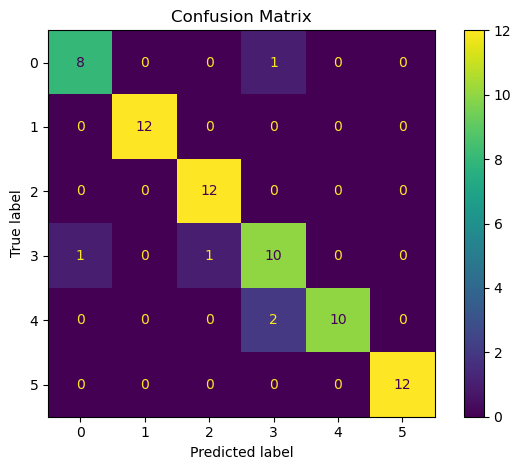

TEST PERFORMANCE
ROC AUC: 0.982638888888889
Accuracy: 0.8947368421052632


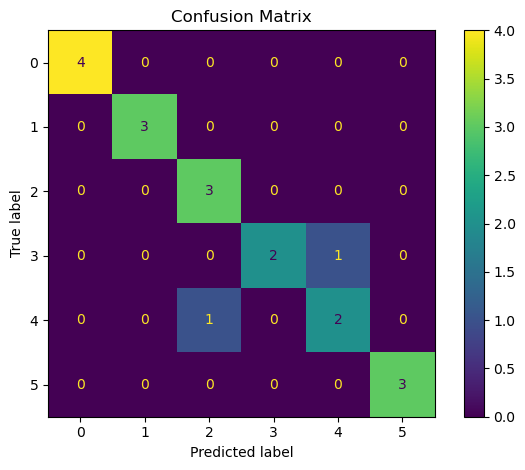

In [31]:
evaluate_nb_model(multi_nb_model, 1)

ii. Comparison

When comparing the results from L1-penalized multinomial regression and Naive Bayes, it appears that Naive Bayes is the more effective method for the multi-class classification problem. Both types of NB methods perform similarly, however, Multinomial NB has a slightly higher AUC ROC on the testing data despite having the same accuracy. Interestingly, the Multinomial Naive Bayes method has worse training accuracy than the L1-penalized multinomial regression. However, the Multinomial NB method generalizes noticeably better on the testing data then the multinomial regression.  